## Ejercicio Formativo 2 Capítulo 1

## Tema elegido: Transporte

Se define una clase base llamada `Vehiculo` y dos clases derivadas: `Auto` y `Bicicleta`. 
Además, se incorpora la clase `Motor`, la cual forma parte de la clase `Auto` como atributo.

### Clase Vehiculo

La clase `Vehiculo` representa un medio de transporte general. 
Se utiliza como clase base para compartir atributos comunes, como el nombre y la velocidad máxima. 
También define el método `mover()`, que será implementado por las clases hijas.

In [45]:
from abc import ABC, abstractmethod

# clase base abstracta
class Vehiculo(ABC):
    def __init__(self, nombre, velocidad_max):
        self.nombre = nombre
        self.velocidad_max = velocidad_max
    
    @abstractmethod
    def mover(self):
        pass
    
    def __str__(self):
        return f"Vehículo: {self.nombre}, velocidad máxima: {self.velocidad_max} km/h"


### Clase Motor

La clase `Motor` representa el motor de un vehículo motorizado. 
Se utiliza como atributo dentro de la clase `Auto`, mostrando una relación de composición entre clases. No existe fuera del Auto

In [46]:
# clase que sera atributo de otra
class Motor:
    def __init__(self, nombre, tipo_combustible, cilindrada):
        self.nombre = nombre
        self.tipo_combustible = tipo_combustible
        self.cilindrada = cilindrada
    
    def __str__(self):
        return f"Motor {self.nombre} - {self.tipo_combustible}, {self.cilindrada} cc"

### Clase Auto

La clase `Auto` hereda de `Vehiculo` y representa un vehículo motorizado. 
Contiene un objeto de tipo `Motor` como atributo y redefine el método `mover()`.

In [47]:
# clase hija 1
class Auto(Vehiculo):
    def __init__(self, nombre, velocidad_max, puertas, nombre_motor, tipo_combustible, cilindrada):
        super().__init__(nombre, velocidad_max)
        self.puertas = puertas
        self.motor = Motor(nombre_motor, tipo_combustible, cilindrada) # fijense que esta definido dentro, asi que composición.
    
    def mover(self):
        return f"El auto {self.nombre} se mueve usando su motor."
    
    def __str__(self):
        return (f"Auto: {self.nombre}, velocidad máxima: {self.velocidad_max} km/h, "
                f"puertas: {self.puertas}, motor: [{self.motor}]")


### Clase Bicicleta

La clase `Bicicleta` hereda de `Vehiculo` y representa un medio de transporte no motorizado. 
También redefine el método `mover()`, mostrando polimorfismo.

In [48]:
# clase hija 2
class Bicicleta(Vehiculo):
    def __init__(self, nombre, velocidad_max, tipo):
        super().__init__(nombre, velocidad_max)
        self.tipo = tipo
    
    def mover(self):
        return f"La bicicleta {self.nombre} se mueve al pedalear."
    
    def __str__(self):
        return (f"Bicicleta: {self.nombre}, velocidad máxima: {self.velocidad_max} km/h, "
                f"tipo: {self.tipo}")

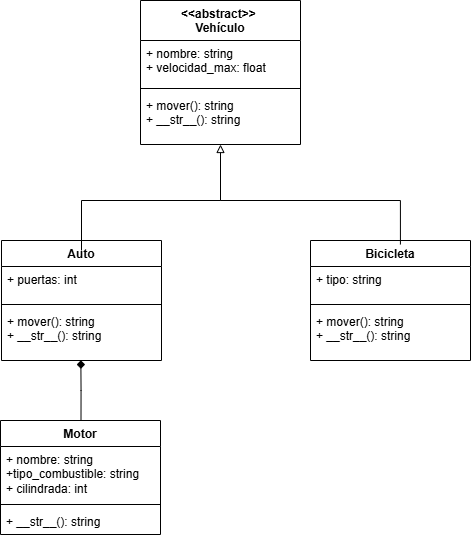

In [49]:
from PIL import Image
from IPython.display import display

imagen = Image.open("image.png")
display(imagen)

Noten que la relación entre Auto y Vehículo, Bicicleta y Vehículo es de Herencia, lo que es DISTINTO a Agregación. Ojo con eso. 
La relación entre Auto y Motor es Composición, porque se ve que el motor no existe fuera del auto. Revisen los notebooks del Capítulo 1.

Diagrama hecho con https://app.diagrams.net/ (draw.io)

### Creación de instancias

In [50]:
auto1 = Auto("AutoRojo", 180, 4, "EcoBoost", "Bencina", 1600)
auto2 = Auto("CamionetaAzul", 160, 2, "TDI", "Diésel", 2000)

bici1 = Bicicleta("BiciMontaña", 45, "Montaña")
bici2 = Bicicleta("BiciRuta", 50, "Ruta")

In [51]:
# mostrar objetos
print(auto1)
print(auto2)
print(bici1)
print(bici2)

Auto: AutoRojo, velocidad máxima: 180 km/h, puertas: 4, motor: [Motor EcoBoost - Bencina, 1600 cc]
Auto: CamionetaAzul, velocidad máxima: 160 km/h, puertas: 2, motor: [Motor TDI - Diésel, 2000 cc]
Bicicleta: BiciMontaña, velocidad máxima: 45 km/h, tipo: Montaña
Bicicleta: BiciRuta, velocidad máxima: 50 km/h, tipo: Ruta


In [52]:
# mostrar polimorfismo
print(auto1.mover())
print(bici1.mover())

El auto AutoRojo se mueve usando su motor.
La bicicleta BiciMontaña se mueve al pedalear.


In [53]:
vehiculos_lista = [auto1, auto2, bici1, bici2]

vehiculos_diccionario = {
    auto1.nombre: auto1,
    auto2.nombre: auto2,
    bici1.nombre: bici1,
    bici2.nombre: bici2
}

In [54]:
print(vehiculos_diccionario)

{'AutoRojo': <__main__.Auto object at 0x000001F00AD8EE30>, 'CamionetaAzul': <__main__.Auto object at 0x000001F00AF5FEB0>, 'BiciMontaña': <__main__.Bicicleta object at 0x000001F00AD8EC20>, 'BiciRuta': <__main__.Bicicleta object at 0x000001F00AD8EF20>}


## Comparación entre lista y diccionario

Si se necesita buscar un objeto por su nombre específico, la estructura más rápida es el diccionario. 
Sucede que en el diccionario se accede directamente al objeto a partir de su clave, que en este caso corresponde al nombre. 

En cambio, para una lista es necesario recorrer los elementos uno por uno hasta encontrar el objeto buscado. 
Por ello, para búsquedas por nombre, el diccionario resulta más eficiente.

In [55]:
def buscar_en_lista(lista, nombre):
    for vehiculo in lista:
        if vehiculo.nombre == nombre:
            return vehiculo
    return None

def buscar_en_diccionario(diccionario, nombre):
    return diccionario.get(nombre, None)

# elegimos el ultimo de la lista, que es la bici2.
nombre_buscado = "BiciRuta"

10.000 veces para reducir el ruido entre cada iteracion, probamos buscar el nombre por cada forma.

In [56]:
import time
tiempos_lista = []
tiempos_diccionario = []

for _ in range(10000):
    t0 = time.perf_counter()
    resultado_lista = buscar_en_lista(vehiculos_lista, nombre_buscado)
    t1 = time.perf_counter()

    t2 = time.perf_counter()
    resultado_diccionario = buscar_en_diccionario(vehiculos_diccionario, nombre_buscado)
    t3 = time.perf_counter()

    tiempos_lista.append(t1 - t0)
    tiempos_diccionario.append(t3 - t2)



In [57]:
print(f"Tiempo promedio de búsqueda en lista: {sum(tiempos_lista) / len(tiempos_lista):.10f} segundos")
print(f"Tiempo promedio de búsqueda en diccionario: {sum(tiempos_diccionario) / len(tiempos_diccionario):.10f} segundos")

Tiempo promedio de búsqueda en lista: 0.0000003072 segundos
Tiempo promedio de búsqueda en diccionario: 0.0000001719 segundos


Como extra (fuera del curso), los resultados muestran que la búsqueda en diccionario es significativamente más rápida que en una lista. 
Esto se debe a que el diccionario permite acceso directo mediante claves (complejidad promedio O(1)), 
mientras que la lista requiere recorrer los elementos secuencialmente (O(n)).